In [7]:
import torch

from tqdm import tqdm
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [8]:
class NnetMNISTclassificator(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input_layer = nn.Linear(inputs, outputs)
        self.activation_function = nn.functional.relu

    def forward(self, x):
        x = self.flatten(x)
        x = self.input_layer(x)
        x = self.activation_function(x)
        return x

In [18]:
class CnnMNISTclassificator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(32 * 14 * 14, 128)
        self.dropout = nn.Dropout(0.5)
        self.output_layer = nn.Linear(128, 10)

        self.activation_fn1 = nn.functional.relu

    def forward(self, x):
        x = self.pool1(self.activation_fn1(self.bn1(self.conv1(x))))

        x = self.flatten(x)
        x = self.activation_fn1(self.hidden1(x))
        x = self.dropout(x)
        x = self.output_layer(x)
        return x


In [22]:
class DeepTrainer:
    def __init__(self, train_data, test_data):
        self.train_data = train_data
        self.test_data = test_data
        self.train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
        self.test_loader = DataLoader(test_data, batch_size=100, shuffle=False)

        self.model = CnnMNISTclassificator()

    def train_test(self):
        loss_function = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr = 0.001)

        epochs = 10
        for epoch in tqdm(range(epochs)):
            self.model.train()
            for index, data in tqdm(enumerate(self.train_loader)):
                x_train, y_train = data 
                optimizer.zero_grad()
                y_pred = self.model(x_train)
                loss = loss_function(y_pred, y_train)
                loss.backward()
                optimizer.step()
        
        correct = 0
        total = 0
        self.model.eval()
        with torch.no_grad():
            for data in tqdm(self.test_loader):
                x_test, y_test = data
                outputs = self.model(x_test)
                _, predicted = torch.max(outputs.data, 1)

                total += y_test.size(0)
                correct += (predicted == y_test).sum().item()

        print(f"Accuracy: {correct / total}")


In [23]:
transform = transforms.Compose([
    transforms.ToTensor(),           # (1, 28, 28)
    #transforms.Flatten(),            # (784)  
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("./data", train=False, download=True, transform=transform)

trainer = DeepTrainer(train_data, test_data)
trainer.train_test()

938it [00:35, 26.31it/s]0:00<?, ?it/s]
938it [00:33, 27.94it/s]0:35<05:20, 35.65s/it]
938it [00:33, 27.98it/s]1:09<04:35, 34.43s/it]
938it [00:33, 27.73it/s]1:42<03:58, 34.02s/it]
938it [00:34, 27.46it/s]2:16<03:23, 33.95s/it]
938it [00:34, 27.36it/s]2:50<02:50, 34.02s/it]
938it [00:33, 28.05it/s]3:25<02:16, 34.11s/it]
938it [00:34, 27.09it/s]3:58<01:41, 33.89s/it]
938it [00:34, 27.45it/s]4:33<01:08, 34.13s/it]
938it [00:36, 25.94it/s]5:07<00:34, 34.14s/it]
100%|██████████| 100/100 [00:03<00:00, 27.23it/s]

Accuracy: 0.9865


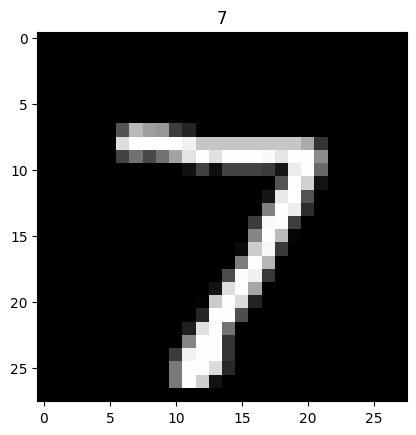

torch.return_types.max(
values=tensor([16.6392]),
indices=tensor([7]))


In [39]:
import matplotlib.pyplot as plt

data, labels = test_data[0]
plt.imshow(data.squeeze().numpy(), cmap='gray')
plt.title(labels)
plt.show()

pred = torch.max(trainer.model(data.unsqueeze(0)).data, 1)
print(pred)